# Analyze a single Xenium sample using Python

**This vignette is part of [The Xenium In Situ Gene Expression Data Analysis Workshop](https://www.10xgenomics.com/analysis-guides/workshop-xenium-in-situ-analysis)**

*Updated May 5th 2026*

How to use this Google Colab

- Select Python as the programming language: Click “Runtime -> Change runtime type”, then ensure “Runtime type” is set to “Python”. There could be resource usage [limitations](https://research.google.com/colaboratory/faq.html#usage-limits).
- Click the “Connect” button on the top-right corner. Now, you are ready to run the tutorial.
- You can run the analysis using the data we provided in the code. Alternatively, you can also load your own data.

# **1. Install and import packages**

First let's install and import the packages we need.
The spatialdata/scverse Python ecosystem offers a comprehensive and unified framework for analyzing Xenium data.
Key Python libraries like `spatialdata` (for core data structures and operations), `spatialdata-io` (for importing Xenium data) and `spatialdata-plot` (for static plotting) facilitate data handling, analysis, and visualization.

More information can be found in the `spatialdata` documentation: https://spatialdata.scverse.org/en/stable/.

In [1]:
# Install required python packages (takes ~1 min)
#'!' is used when using bash command instead of python in this Colab notebook
!uv pip install scanpy==1.11.2 spatialdata[extra]==0.4.0 scikit-misc==0.5.1 squidpy==1.6.5 harmonypy==0.0.10 geosketch==1.3 igraph==0.11.8 pyarrow==21.0.0 datashader==0.18.2 distributed

# import the python packages
import scanpy as sc
import spatialdata as sd
import pandas as pd
import numpy as np
import h5py
import anndata as ad
import spatialdata_io as sio
import spatialdata_plot
import matplotlib.pyplot as plt
import warnings
import os
import squidpy as sq
import anndata as ad
import gc

warnings.filterwarnings("ignore")

Using Python 3.12.13 environment at: /usr
Resolved 204 packages in 5.36s
Prepared 92 packages in 11.14s
Uninstalled 4 packages in 64ms
Installed 92 packages in 343ms
 + aiobotocore==2.26.0
 + aioitertools==0.13.0
 + anndata==0.12.19
 + app-model==0.5.1
 + array-api-compat==1.15.0
 + asciitree==0.3.3
 + botocore==1.41.5
 + build==1.5.0
 + cachey==0.2.1
 + colorama==0.4.6
 - dask==2026.6.0
 + dask==2024.11.2
 + dask-image==2026.5.0
 + datashader==0.18.2
 + deprecated==1.3.1
 + distributed==2024.11.2
 + docrep==0.3.2
 + fasteners==0.20
 + fbpca==1.0
 + flexcache==0.3
 + flexparser==0.4
 + flowio==1.4.0
 + freetype-py==2.5.1
 + geosketch==1.3
 + harmonypy==0.0.10
 + heapdict==1.0.1
 + hsluv==5.0.4
 + igraph==0.11.8
 + imagecodecs==2026.3.6
 + in-n-out==0.2.1
 + ipython-pygments-lexers==1.1.1
 + jedi==0.20.0
 + jmespath==1.1.0
 + legacy-api-wrap==1.5
 + loguru==0.7.3
 + magicgui==0.10.2
 + matplotlib-scalebar==0.9.0
 + multiscale-spatial-image==2.0.3
 + napari==0.7.1
 + napari-console==0.1.

/usr/local/lib/python3.12/dist-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.12/dist-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.12/dist-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.

# **2. Xenium data initialization and analysis**

## 2.1 Download and convert Xenium output bundle to Zarr

In this notebook, we will work on the Xenium Prime Breast Cancer data. The code block below details how to convert Xenium output bundle into Python zarr format that can be use for further analysis.

We commented out this section (added '#' in front of each line), because it may take a while to run during a hands-on workshop. If you are using this notebook to analyze your own data, remove the '#'s and load your own Xenium output bundle.

To load your own data, upload your zipped Xenium output bundle into the CoLab environment. Select "Files" in the the left-hand navigation panel and "Upload to session storage" and select your zipped Xenium output bundle. Once that is complete, you can proceed with the !unzip line of the following commented code block. Be sure to change the file names to match your data.

In [ ]:
# # Download and unzip Xenium Prime Breast Cancer output bundle
# !wget https://s3-us-west-2.amazonaws.com/10x.files/samples/xenium/3.0.0/Xenium_Prime_Breast_Cancer_FFPE/Xenium_Prime_Breast_Cancer_FFPE_outs.zip
# !unzip Xenium_Prime_Breast_Cancer_FFPE_outs.zip -d Xenium_Prime_Breast_Cancer_FFPE_outs

# # Convert Xenium output bundle into a SpatialData object
# sdata = sio.xenium("Xenium_Prime_Breast_Cancer_FFPE_outs/")

# # We delete the image as it takes up a lot of memory and we do not use for this analysis
# del sdata['morphology_focus']

# # Save the SpatialData object as .zarr data bundle for fast data loading and processing in Python
# sdata.write("breast.zarr")

For the convenience of workshop attendees, we have already converted the Xenium Prime Breast Cancer data into a Python Zarr file.

**Important note:** The Zarr format used by spatialdata differs from the cells.zarr.zip, transcripts.zarr.zip and analysis.zarr.zip used in the Xenium bundle.

In [2]:
# Download and unzip the already converted data, it will take ~1 min
!wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/breast.zarr.zip
!unzip breast.zarr.zip
!rm breast.zarr.zip

--2026-07-03 11:44:42--  https://cf.10xgenomics.com/supp/xenium/analysis-workshop/breast.zarr.zip
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2950843591 (2.7G) [application/zip]
Saving to: ‘breast.zarr.zip’

breast.zarr.zip     100%[===================>]   2.75G   120MB/s    in 29s     

2026-07-03 11:45:12 (96.3 MB/s) - ‘breast.zarr.zip’ saved [2950843591/2950843591]

Archive:  breast.zarr.zip
   creating: breast.zarr/
   creating: breast.zarr/tables/
  inflating: breast.zarr/.zattrs     
  inflating: breast.zarr/.zgroup     
   creating: breast.zarr/labels/
   creating: breast.zarr/shapes/
  inflating: breast.zarr/zmetadata   
   creating: breast.zarr/points/
  inflating: breast.zarr/tables/.zgroup  
   creating: breast.zarr/tables/table/
  inflating: breast.zarr/labels/.zattrs  
  in

## 2.2 Load SpatialData object

We will load the data into a SpatialData object to work on.

A SpatialData object is a container for various spatial omics data elements, such as images, labels, points, shapes, and tables. These objects are stored on disk as `.zarr` stores, which are essentially structured folders containing data and metadata.

In [3]:
# Read zarr to SpatialData
sdata = sd.read_zarr("breast.zarr/")

# Take a look at the SpatialData object
sdata

SpatialData object, with associated Zarr store: /content/breast.zarr
├── Labels
│     ├── 'cell_labels': DataTree[yx] (74945, 51265), (37472, 25632), (18736, 12816), (9368, 6408), (4684, 3204)
│     └── 'nucleus_labels': DataTree[yx] (74945, 51265), (37472, 25632), (18736, 12816), (9368, 6408), (4684, 3204)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (699110, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (699110, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (692184, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (699110, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

**Quiz:** What do the numbers (699110, 5101) mean?

In [8]:
sdata.table.var

,gene_ids,feature_types,genome
A2ML1,ENSG00000166535,Gene Expression,Unknown
AAMP,ENSG00000127837,Gene Expression,Unknown
AAR2,ENSG00000131043,Gene Expression,Unknown
AARSD1,ENSG00000266967,Gene Expression,Unknown
ABAT,ENSG00000183044,Gene Expression,Unknown
...,...,...,...
ZSCAN26,ENSG00000197062,Gene Expression,Unknown
ZSWIM6,ENSG00000130449,Gene Expression,Unknown
ZUP1,ENSG00000153975,Gene Expression,Unknown
ZYG11B,ENSG00000162378,Gene Expression,Unknown


**Quiz:** How would you pull out the AnnData object information?

## 2.3 Downstream analysis of count matrix (`sdata['table']`)

### 2.3.1 Standard data preprocessing

Similar to scRNA-seq analysis, the first step in analyzing the count matrix is quality control (QC). We want to remove cells with low transcript counts. Here, we plot the distribution of transcript counts per cell in a histogram to determine the transcript count cutoff to remove cells with low transcript counts. The determination of cutoff can be subjective. There is no gold-standard rule.  

 We shallow copy with the step `adata = sdata['table']`. Any changes made in adata will be reflected in `sdata['table']`. To make a separate adata object, run `adata = sdata['table'].copy()`.

In [11]:
# Shallow copy the AnnData object information so that we can more quickly process the data
adata = sdata['table']
del(sdata) # Delete sdata to free up memory
# We can store the raw counts in the layers in case we need it for future purposes, like differential expression.
# In this analysis guide, we don't use it, so we comment it out to save space.
# adata.layers["counts"] = adata.X.copy()
adata

AnnData object with n_obs × n_vars = 699110 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

Text(0, 0.5, 'Number of cells')

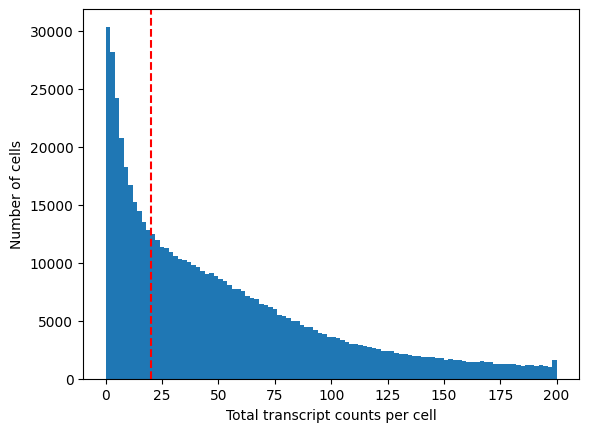

In [12]:
# Create a figure of the total counts across the tissue
fig = plt.hist(adata.obs['transcript_counts'], range=(0, 200), bins=100)
plt.axvline(x=20, color='r', linestyle='--')  # You can customize color and linestyle

plt.xlabel("Total transcript counts per cell")
plt.ylabel("Number of cells")

In [15]:
# Based on the histogram plot, here we choose 20 transcript counts as lower cutoff
thres = np.quantile(adata.obs['transcript_counts'], 0.98)
sc.pp.filter_cells(adata, min_counts=20)
sc.pp.filter_cells(adata, max_counts=thres)

# We also filter out genes that are rarely expressed
sc.pp.filter_genes(adata, min_cells = 100)

In [19]:
adata.shape[1]

5083

**Quiz:** How many cells and genes do we have now?

Next, we find top 2k variable genes in this Xenium Prime data.

The following code is for Xenium Prime data (>5k genes). Here, we used Seurat's "highly variable gene" methodology, but there are other [highly variable genes `flavor` options](https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html)

*Note: If you are analyzing Xenium v1 data, which has fewer than 2k genes, you can use all genes in the panel.*

In [16]:
sc.pp.highly_variable_genes(adata, flavor = "seurat_v3", n_top_genes = 2000)

We proceed with the usual single cell workflow. We first log-normalized the data, and store the log-normalized data in a layer called "lognorm". The "lognorm" data is important for downstream analysis as a lot of the functions work with log-normalized data. Alternatively, you can store it as `adata.raw = adata.copy()`.

In [27]:
adata

AnnData object with n_obs × n_vars = 480821 × 5083
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatialdata_attrs', 'hvg', 'log1p'
    obsm: 'spatial'
    layers: 'lognorm'

In [20]:
# Log Normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

# Scaling of data, we don't center the data here as the data centering is done in PCA and this keeps the X sparse for memory efficiency.
sc.pp.scale(adata, zero_center=False, max_value = 10)

In [ ]:
# # PCA for dimension reduction further by UMAP for downstream analysis, which may take a few minutes
# sc.pp.pca(adata, n_comps=30)
# sc.pp.neighbors(adata, metric = 'cosine')
# # clustering with leiden. We use igraph here as it scales better. The resolution is a hyper-parameter. A higher resolution will output more clusters.
# sc.tl.leiden(adata, flavor = "igraph", n_iterations=-1, resolution = 0.5)

In [ ]:
# # Run UMAP, which may take > 20 mins.
# sc.tl.umap(adata)

In [28]:
del(adata) # Delete adata to free up memory
gc.collect()  # releases the bytes

90696

### 2.3.2 Plot clustering results spatially in slide (Using preprocessed data)

During the workshop, we will load preprocessed data to skip the time-consuming steps above.


In [29]:
# this step will take ~1 min
!wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/breast_processed_v2.zarr.zip
!unzip breast_processed_v2.zarr.zip

--2026-07-03 12:05:40--  https://cf.10xgenomics.com/supp/xenium/analysis-workshop/breast_processed_v2.zarr.zip
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5230192324 (4.9G) [application/zip]
Saving to: ‘breast_processed_v2.zarr.zip’

breast_processed_v2 100%[===================>]   4.87G  60.4MB/s    in 66s     

2026-07-03 12:06:46 (75.4 MB/s) - ‘breast_processed_v2.zarr.zip’ saved [5230192324/5230192324]

Archive:  breast_processed_v2.zarr.zip
   creating: breast_processed_v2.zarr/
 extracting: breast_processed_v2.zarr/zmetadata  
   creating: breast_processed_v2.zarr/tables/
   creating: breast_processed_v2.zarr/tables/table/
   creating: breast_processed_v2.zarr/tables/table/obs/
   creating: breast_processed_v2.zarr/tables/table/obs/_index/
 extracting: breast_processed_v2.zarr/tab

In [30]:
# Read pre-processed data
sd_data = sd.read_zarr("breast_processed_v2.zarr")

We will next look at the clusters in UMAP space. The clusters were generated based solely on gene expression information. Visualizing our clusters in UMAP space can help us see how our clusters separate based on their transcriptional profiles alone. We can compare this to their location in the spatial context within the tissue.

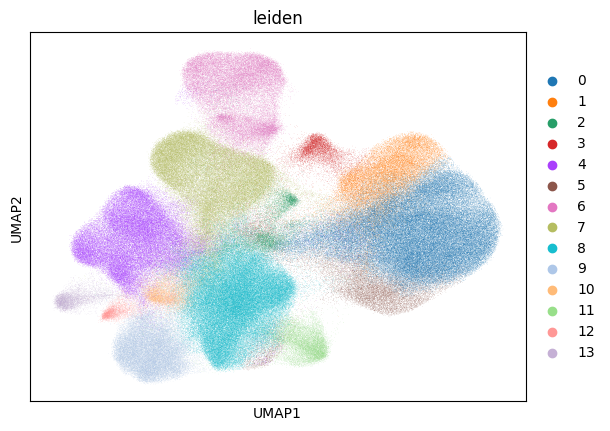

In [31]:
#Sub-set the AnnData object so we can work with just the gene expression information
adata = sd_data['table']
#Plot the umap
sc.pl.umap(adata, color = 'leiden')

### 2.3.3 Export clustering results and visualize in Xenium Explorer


After data processing in python, we can also visulize the new clustering results in [Xenium Explorer](https://www.10xgenomics.com/support/software/xenium-explorer/latest). The steps below show how to export the information to load into Xenium Explorer.

In [32]:
clustering_res = adata.obs[["cell_id", "leiden"]]
clustering_res.columns = ["cell_id","group"]
clustering_res.head()

,cell_id,group
0,aaaaaohf-1,0
2,aaaafefl-1,5
4,aaaahjao-1,0
5,aaaajdej-1,0
6,aaaakcik-1,0


In [33]:
# save the new clusters to clustering_res.csv
clustering_res.to_csv("clustering_res.csv", index = False)

Follow the instructions below to upload the `clustering_res.csv` into Xenium Explorer.

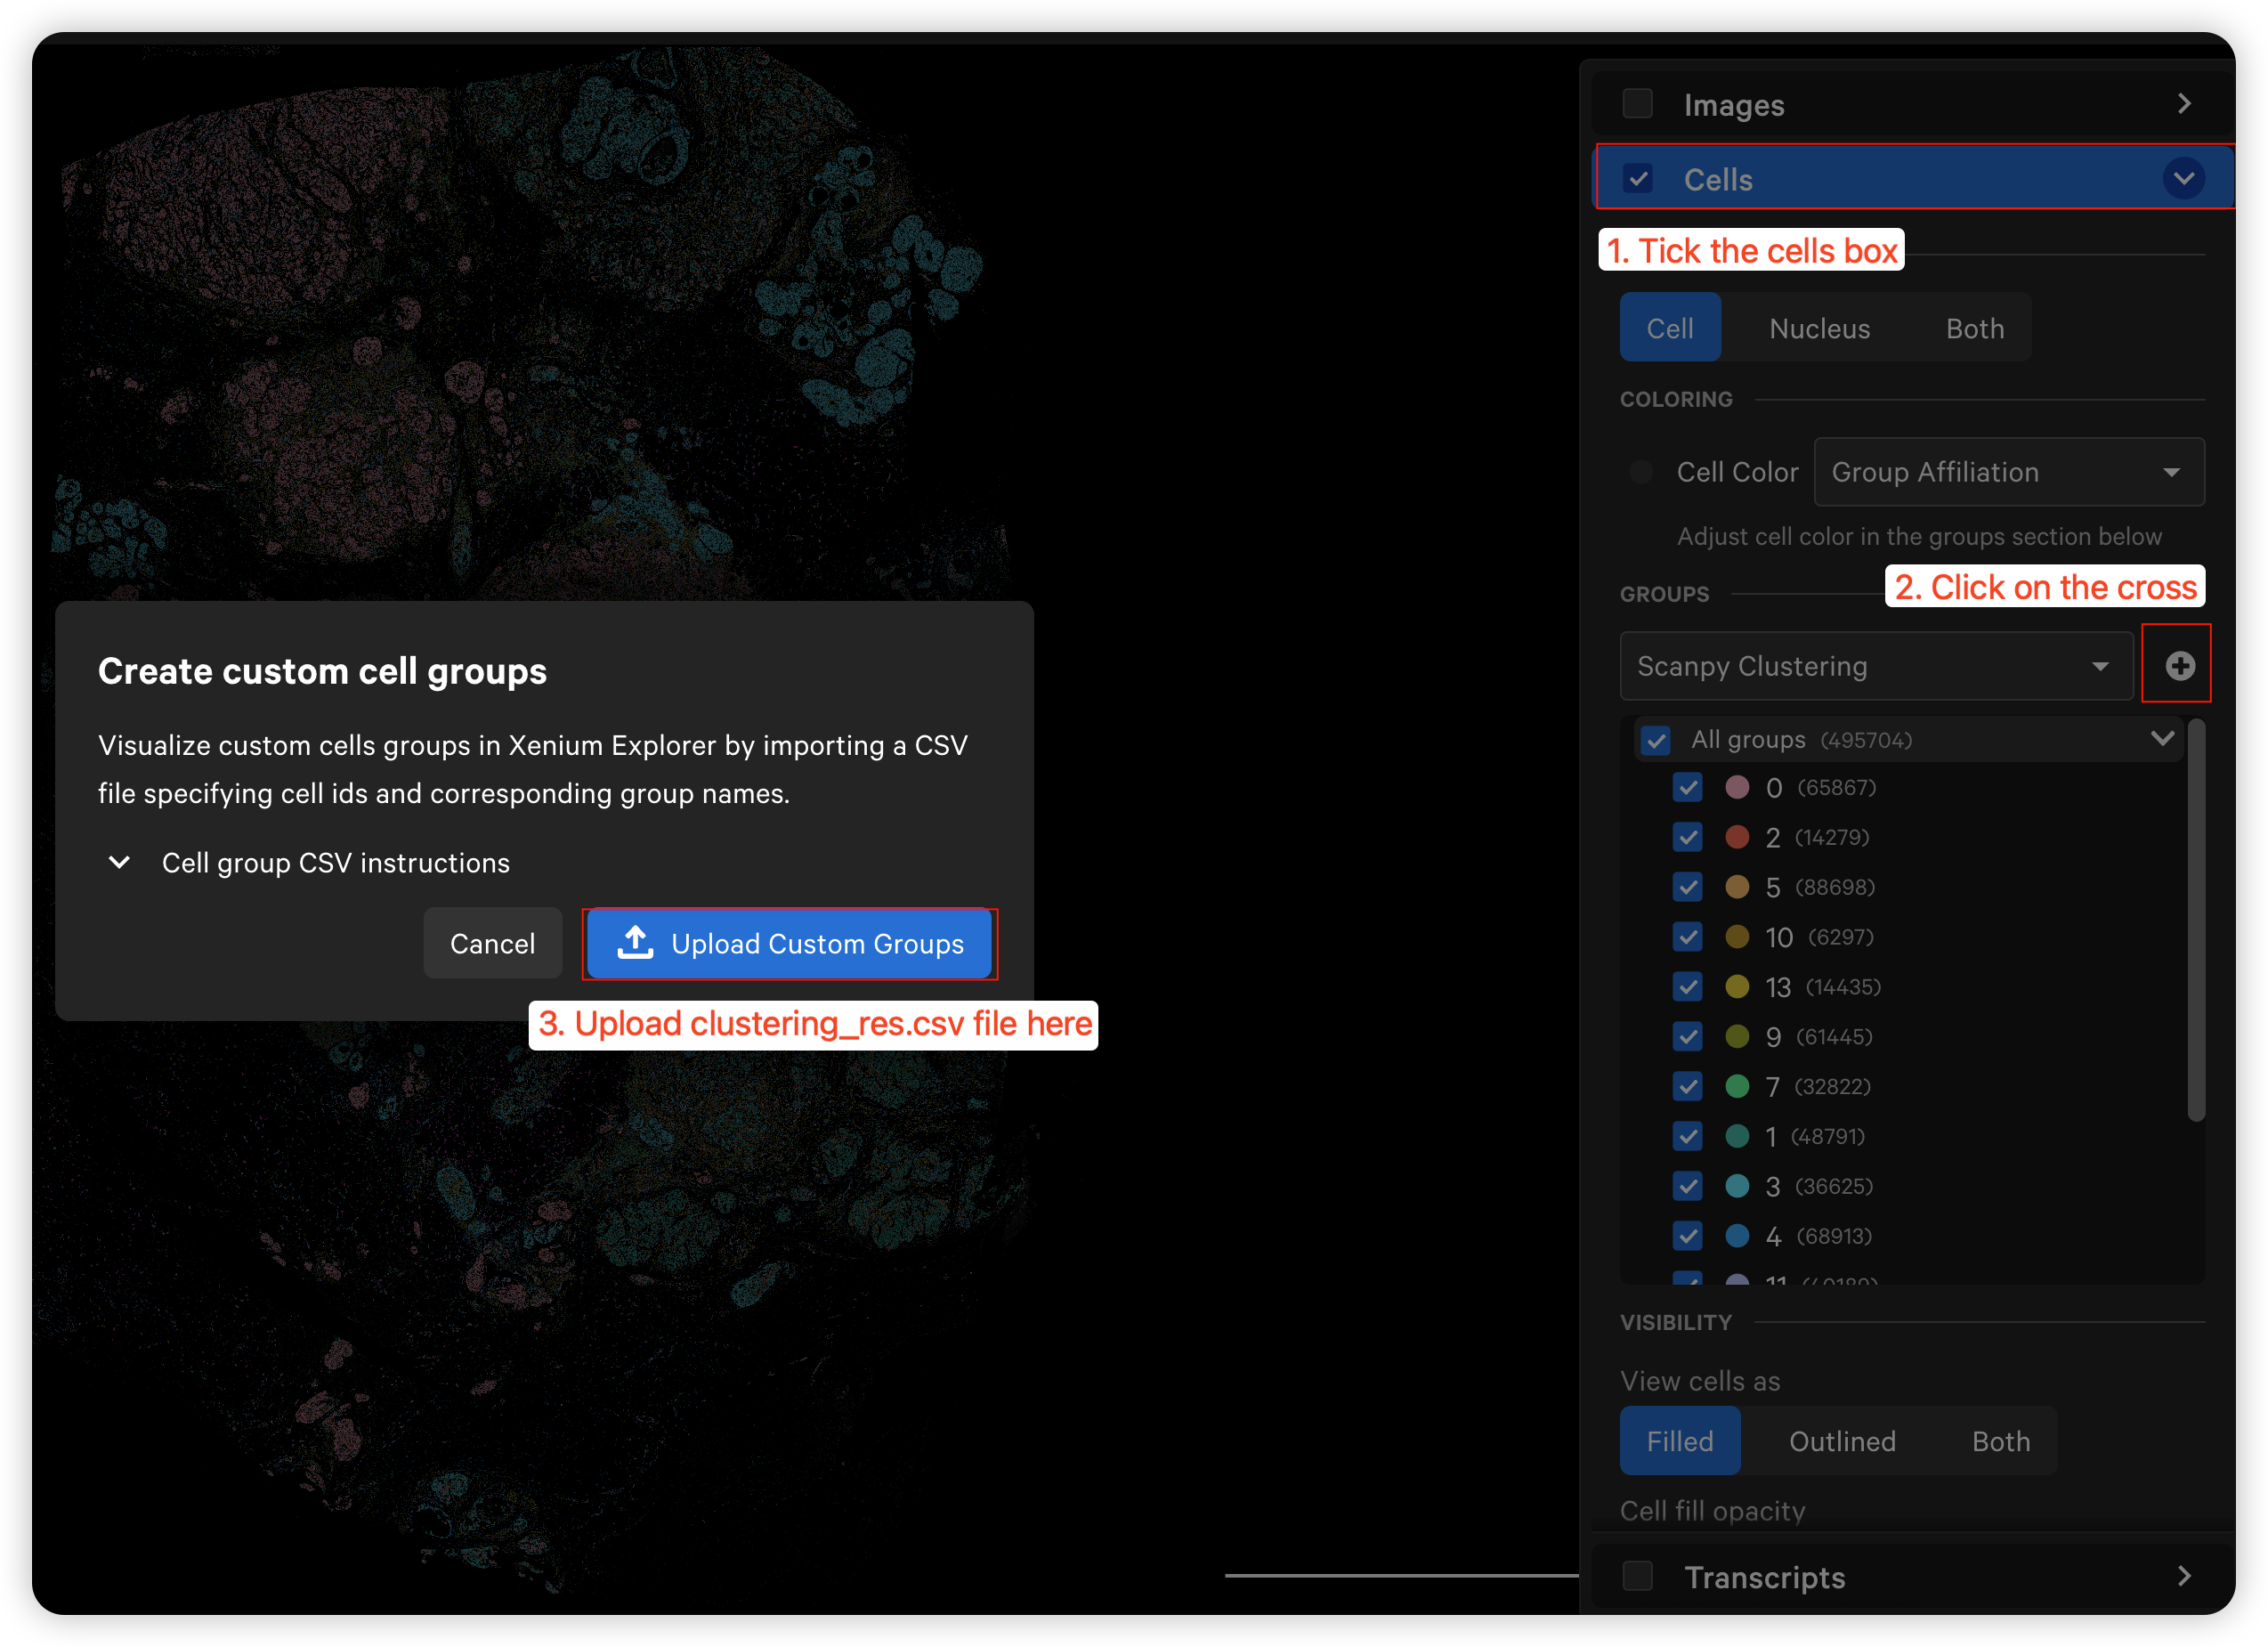

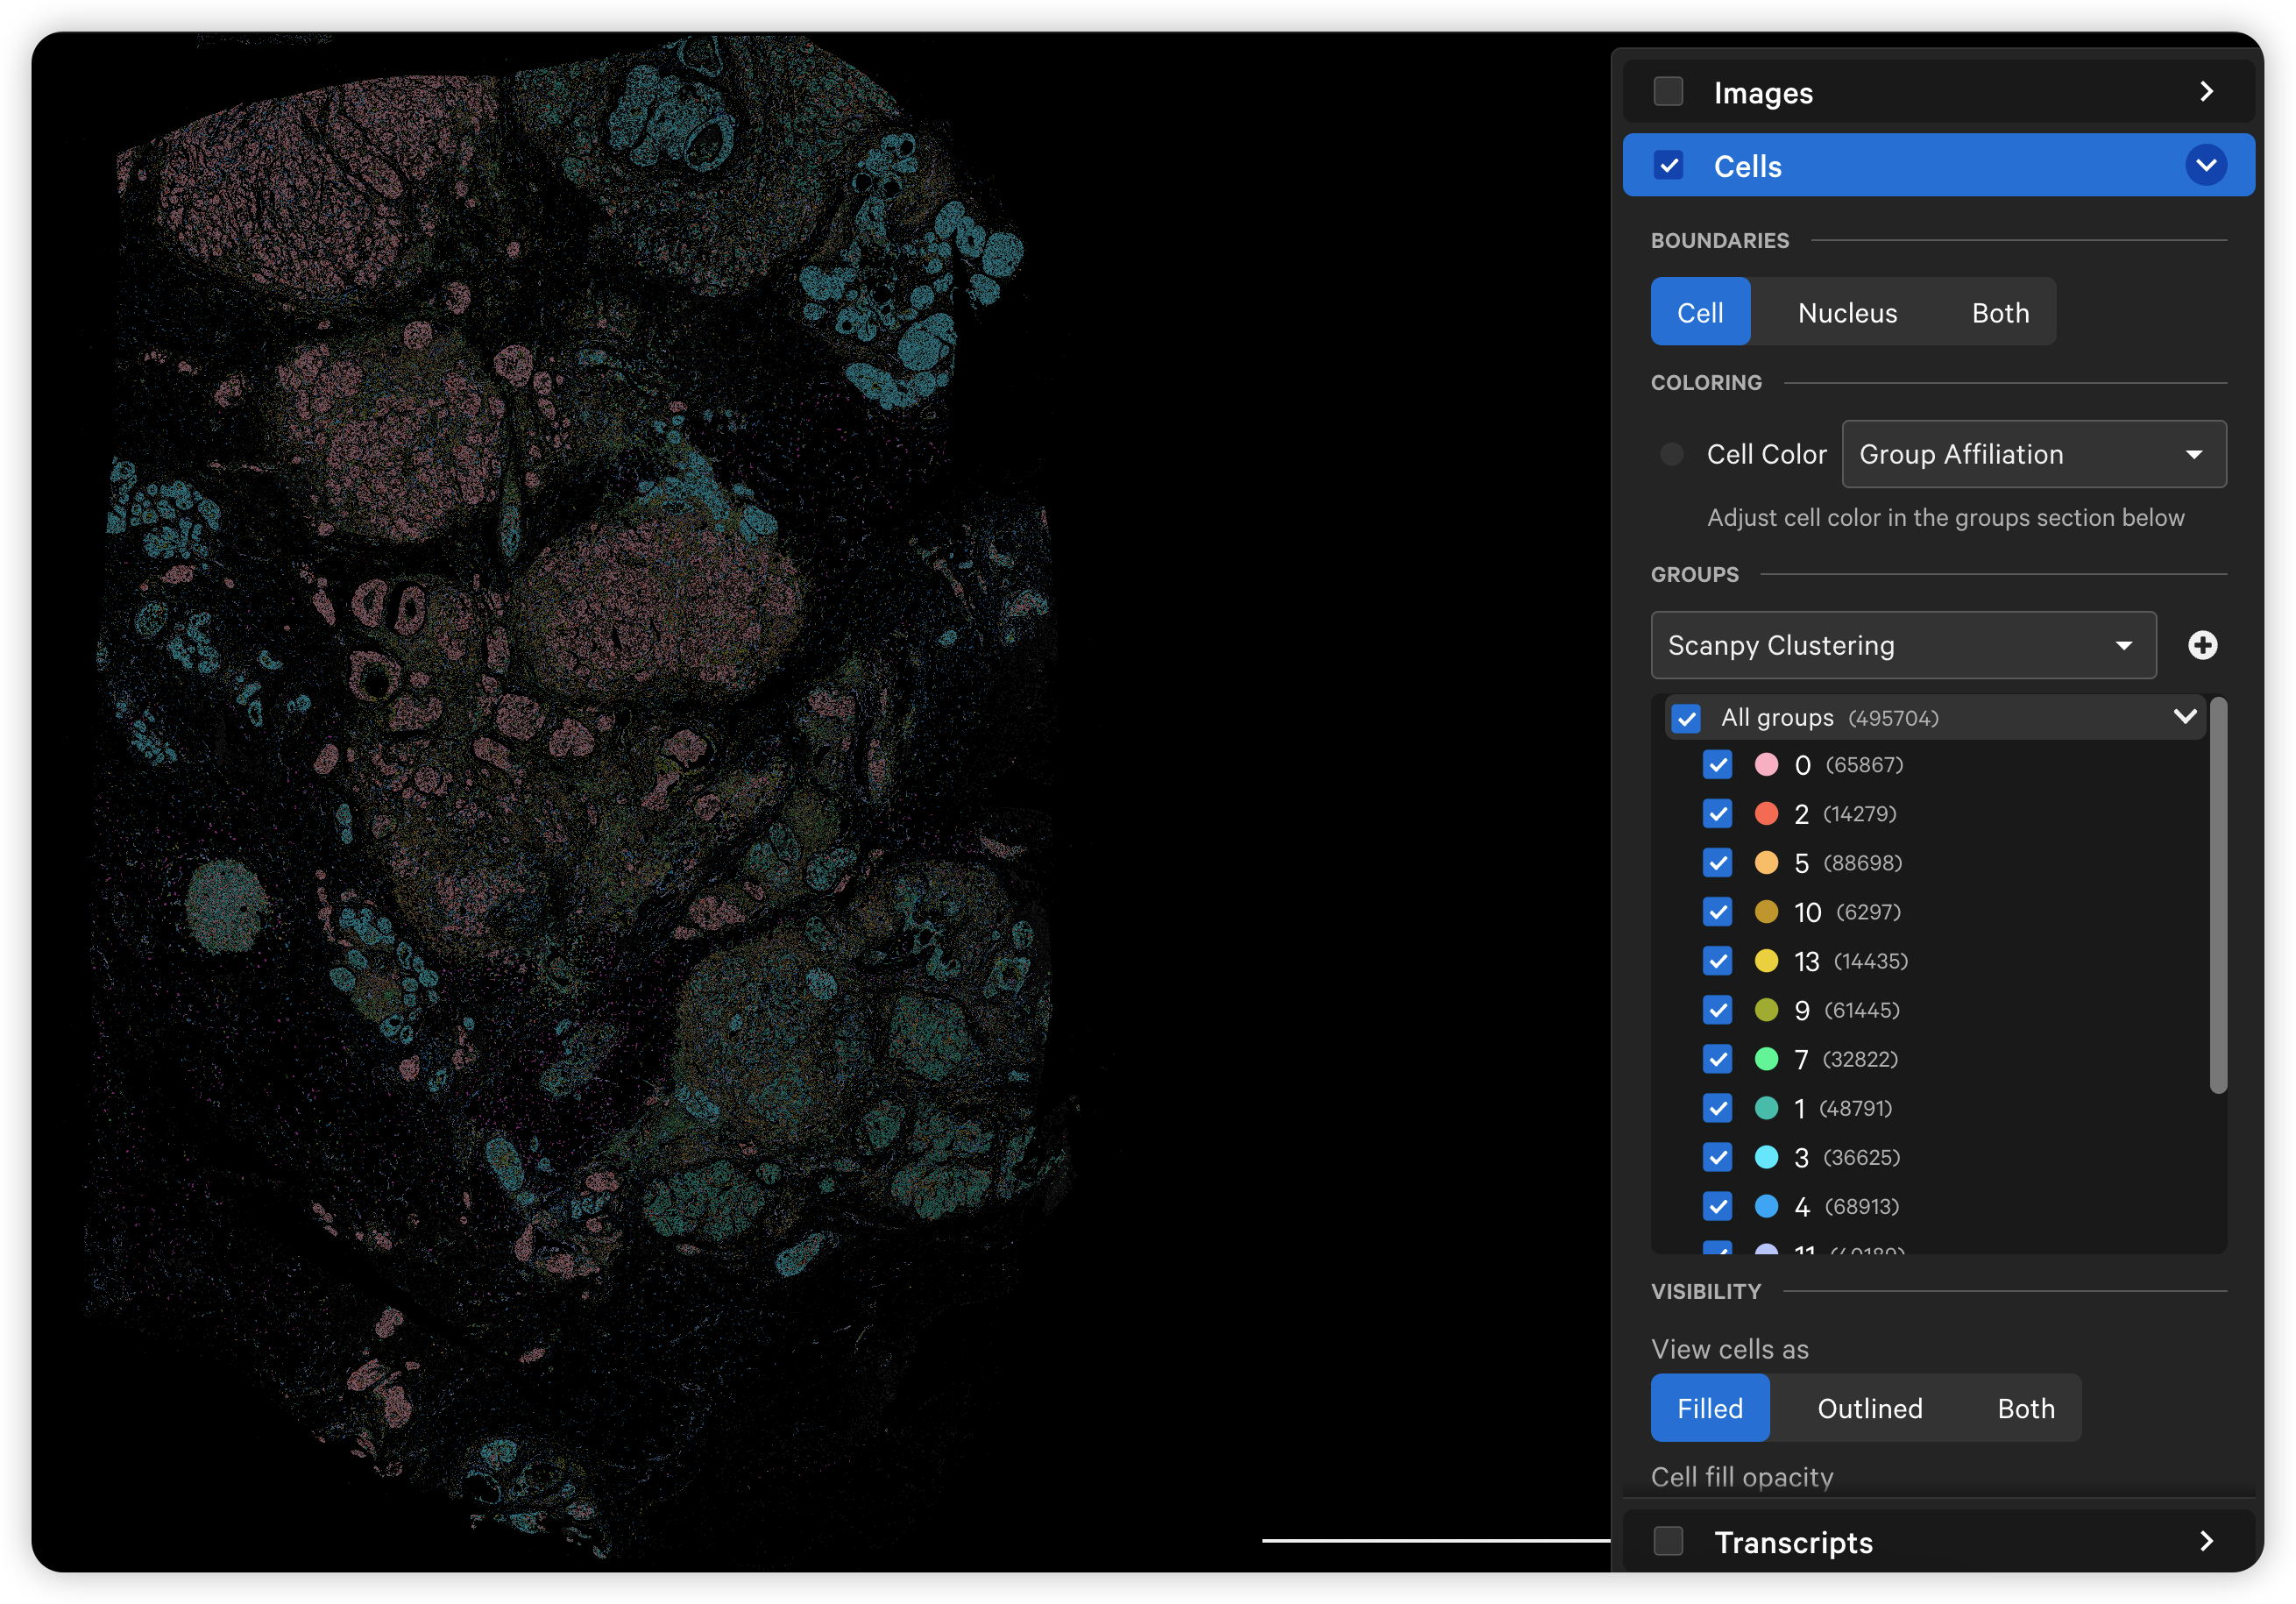

### 2.3.4 Find marker genes for each cluster for cell annotation

Use Scanpy's function `sc.tl.tl_genes_group` to identify marker genes in each cluster. By setting `pts=True`, it returns the percentage of cells that express each gene. In Scanpy, the functions are very flexible, and it is up to the user to provide the right data. For `sc.tl.rank_gene_groups`, it expects log-normalized data, therefore we set the `layer = "lognorm"` here. You can also find the detailed tutorial here: https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.rank_genes_groups.html

In [34]:
# might take ~1 min to run
sc.tl.rank_genes_groups(adata, groupby = "leiden", layer = "lognorm", pts=True)

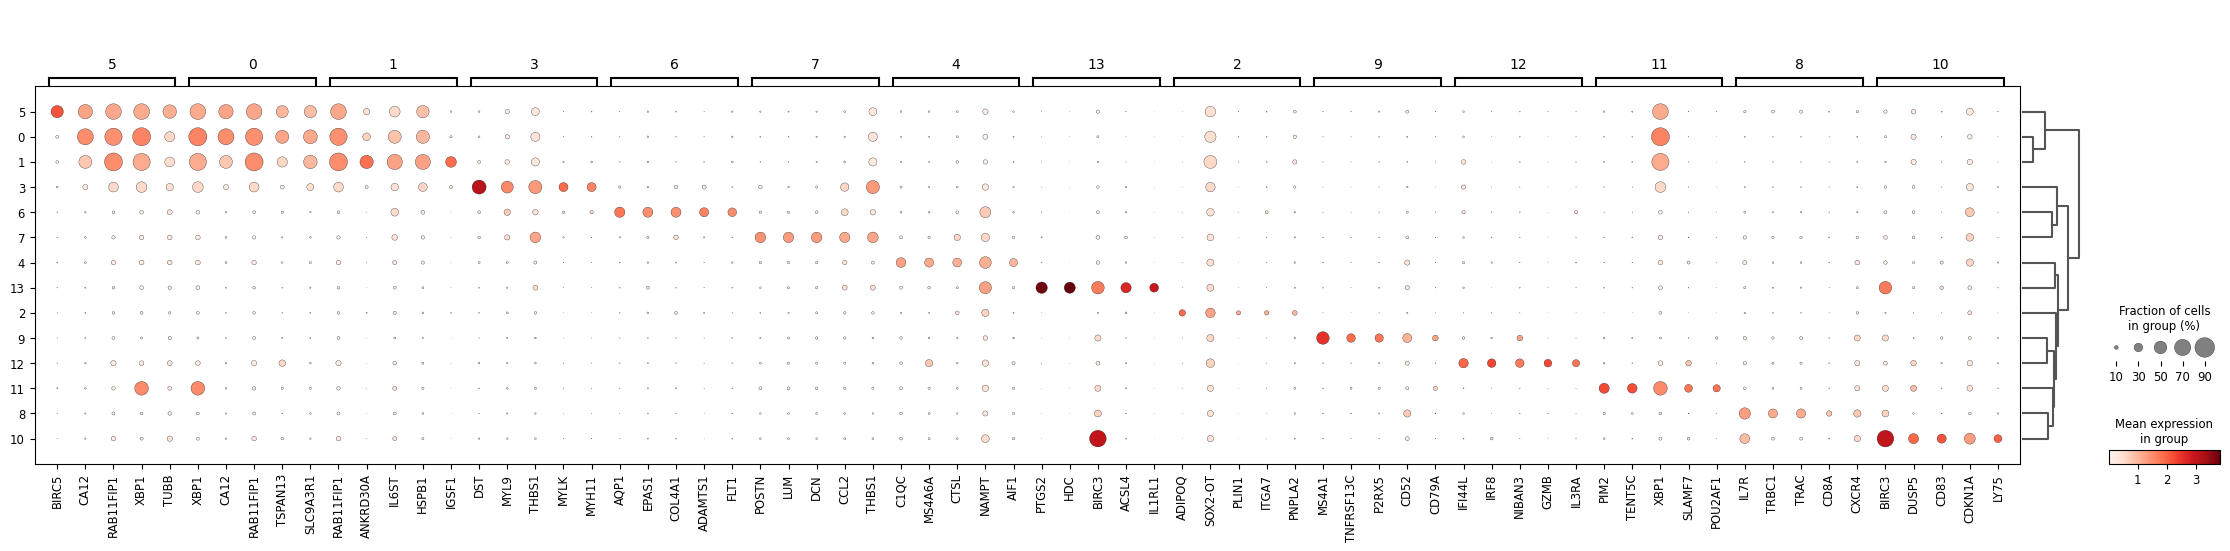

In [35]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)

**Quiz:** What cell types do you think clusters 5, 0, and 1 represent?

### 2.4.5 Cell annotation based on marker genes in each cluster

Based on the marker genes in each cluster, we can identify each cell type.

Here we are sharing one possible way to annotate each cluster.

- Step 1: Get marker genes in each cluster.
- Step 2: Find cell type that is highly associated with the provided marker genes via third-party tools, such as [Enrichr](https://maayanlab.cloud/Enrichr/).
- Step 3: Check spatial location of that cluster in Xenium Explorer (together with H&E image if available) and confirm its cell identity (some clusters' cell identities can be further supported by their spatial locations, such as tumor, vascular endothelial, etc.).


**Using "cluster 6" as an example below:**

In [36]:
markers = sc.get.rank_genes_groups_df(adata, group = "6")
markers.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,AQP1,128.203278,5.606998,0.0,0.0,0.377528,0.012595
1,EPAS1,120.322365,4.069236,0.0,0.0,0.366792,0.031044
2,COL4A1,120.198311,3.911374,0.0,0.0,0.363238,0.033037
3,ADAMTS1,114.865318,5.677482,0.0,0.0,0.322272,0.011286
4,FLT1,108.552277,4.578586,0.0,0.0,0.302878,0.021673
5,PLPP3,103.554703,2.949326,0.0,0.0,0.333834,0.056632
6,PLVAP,98.635544,5.726095,0.0,0.0,0.248899,0.006304
7,COL4A2,90.795128,3.595641,0.0,0.0,0.248323,0.023841
8,SOCS3,87.382530,2.018553,0.0,0.0,0.331081,0.095054
9,C11orf96,86.507301,2.706549,0.0,0.0,0.282057,0.058513


In [37]:
# only print the gene names
print(markers.head(10)["names"].to_string(index=False))

    AQP1
   EPAS1
  COL4A1
 ADAMTS1
    FLT1
   PLPP3
   PLVAP
  COL4A2
   SOCS3
C11orf96


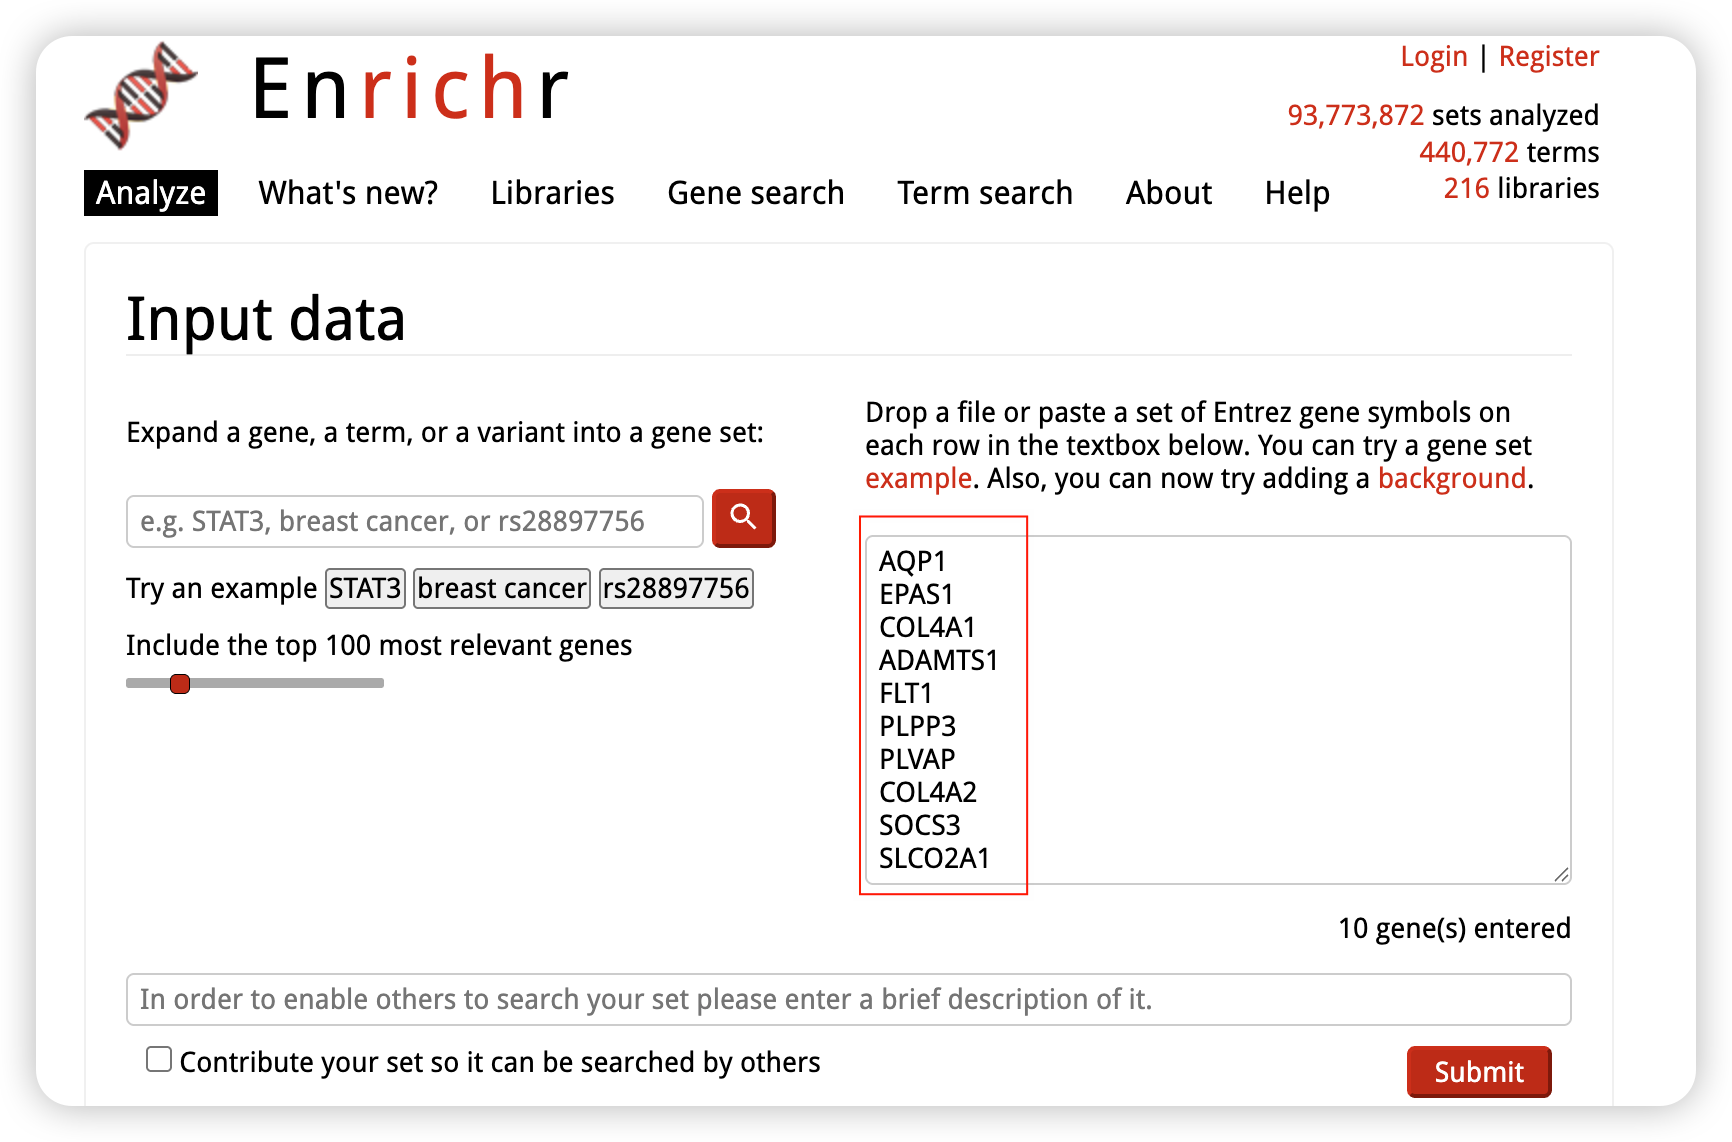

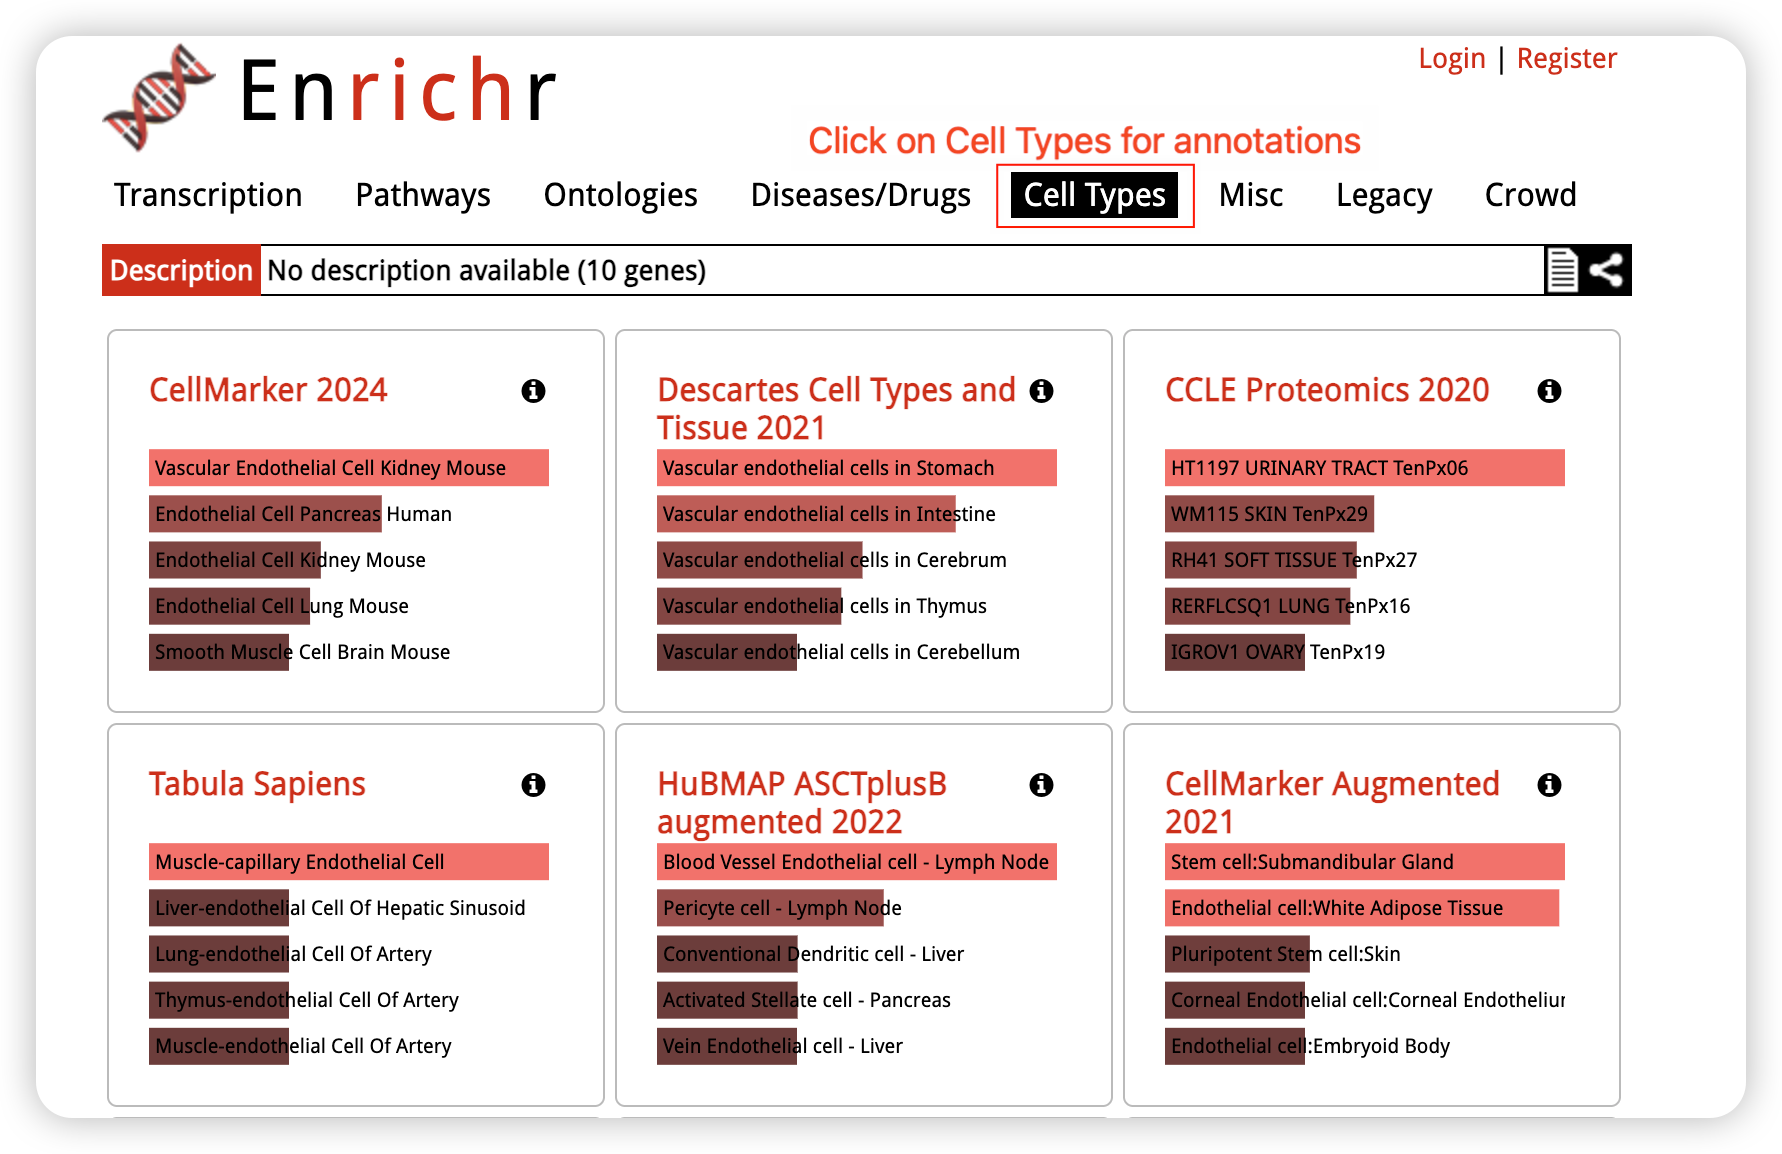

Add the manual cell type annotation to the adata object

In [38]:
# copy the leiden cluster to manual_cell_type
adata.obs['manual_cell_type'] = adata.obs.leiden

# rename cluster 11 to "Endothelial cells"
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('6', 'Endothelial cells')

**Quiz:** What cell type is Cluster 8?

In [43]:
markers = sc.get.rank_genes_groups_df(adata, group = "8")
markers.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,IL7R,212.120453,3.608109,0.0,0.0,0.431250,0.063903
1,TRBC1,177.280991,4.073137,0.0,0.0,0.321353,0.031933
2,TRAC,177.163010,3.902354,0.0,0.0,0.325774,0.035430
3,CD8A,121.042587,4.806633,0.0,0.0,0.165028,0.011287
4,CXCR4,120.272995,2.255139,0.0,0.0,0.244532,0.071645
5,CD52,106.616013,1.863773,0.0,0.0,0.237792,0.085162
6,CTLA4,103.544075,4.388098,0.0,0.0,0.130396,0.011461
7,FYN,101.903152,3.538625,0.0,0.0,0.135536,0.018053
8,CD3E,101.363655,3.897925,0.0,0.0,0.129387,0.012956
9,CD3D,97.731255,3.959720,0.0,0.0,0.120329,0.011501


Similar steps can be applied to annotate all clusters. The process could be time-consuming when there are many clusters. If you have good reference data, automated methods could be used for annotation. An example tutorial can be found here: [Annotating Cell Types in Xenium In Situ Data with Label Transfer](https://www.10xgenomics.com/analysis-guides/xenium-cell-type-annotation)

In [39]:
# @title
# Copy the leiden cluster to manual_cell_type
adata.obs['manual_cell_type'] = adata.obs.leiden

# Annotate all the clusters based on manual annotation
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('0', 'Tumor1')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('1', 'Tumor2')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('2', 'Adipocytes')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('3', 'Smooth Muscle Cells')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('4', 'Macrophages')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('5', 'Tumor3')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('6', 'Endothelial')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('7', 'Fibroblasts')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('8', 'T Cells')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('9', 'B Cells')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('10', 'DCs')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('11', 'Plasma Cells')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('12', 'pDCs')
adata.obs['manual_cell_type'] = adata.obs['manual_cell_type'].replace('13', 'Mast Cells')

In [40]:
# Link processed AnnData table to the spatial element "cell_boundaries"
sd_data.tables["table"].obs["region"] = "cell_boundaries"
sd_data.set_table_annotates_spatialelement("table", region="cell_boundaries")

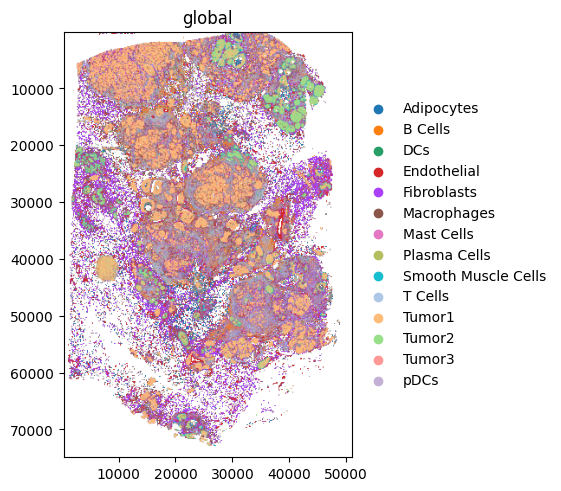

In [41]:
sd_data.pl.render_shapes("cell_boundaries", color="manual_cell_type", method="datashader").pl.show()

### 2.3.6 Export cell type annotations and visualize in Xenium Explorer


In [44]:
manual_cell_type = adata.obs[["cell_id", "manual_cell_type"]]
manual_cell_type.columns = ["cell_id","group"]
manual_cell_type.head()

,cell_id,group
0,aaaaaohf-1,Tumor1
2,aaaafefl-1,Tumor3
4,aaaahjao-1,Tumor1
5,aaaajdej-1,Tumor1
6,aaaakcik-1,Tumor1


In [45]:
# save the new clusters to manual_cell_type.csv
manual_cell_type.to_csv("manual_cell_type.csv", index = False)

Follow the steps in 2.3.3 to visualize the manual cell type annotations in Xenium Explorer.

### 2.3.7 Saving the processed data

We can save the SpatialData object as zarr file for quick loading when we resume data analysis next time.

In [ ]:
# sdata.write("breast_processed.zarr", overwrite = True)

# **3. Spatially aware analysis**


In this section, we include a few methods you can use to further explore Xenium data using spatial-aware methods.

If you are running this section independently from the earlier sections, import the libraries and data using the code blocks below.

### 3.1 Neighborhood enrichment analysis

Neighborhood enrichment analysis calculates an enrichment score by assessing the proximity of cell clusters on the connectivity graph. This score is then compared to a distribution generated through permutations, and a z-score is calculated based on the observed versus expected number of events. This type of analysis can help us answer the following questions:


*   Are there pairs of cell types that tend to appear in close proximity to each other?
*   Are there cell types that are more isolated relative to the rest of the cell types?


In [ ]:
#Compute spatial neighbors. This step may take a few minutes.
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
# Compute neighborhood enrichment
sq.gr.nhood_enrichment(adata, cluster_key="manual_cell_type")

Once the enrichment calculation is complete, we will next plot the results as a heatmap. We will also plot the cell types across our tissue image for side-by-side comparison.

In [ ]:
# Link processed AnnData table to the spatial element "cell_boundaries"
sd_data.tables["table"].obs["region"] = "cell_boundaries"
sd_data.set_table_annotates_spatialelement("table", region="cell_boundaries")

In [ ]:
# Plot the results (takes ~1min)
sq.pl.nhood_enrichment(
    adata,
    cluster_key="manual_cell_type",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    cmap="seismic",      # Red for enrichment, Blue for depletion
    vmin=-750,           # Adjust based on your specific data
    vmax=750
)

Tumor populations show self-enrichment along the diagonal, meaning tumor subpopulations cluster with themselves and with each other, forming the large nodules visible spatially. Tumor3 is found near Tumor1 often.

T Cells, B Cells, DCs, Plasma Cells, and pDCs appear mutually enriched, which may represent organized tertiary lymphoid structures (TLS) — these are associated with better immunotherapy response.

Tumor populations and immune cells are largely blue (depleted), meaning tumor and immune compartments are spatially segregated rather than mixed, which could suggest limited immune infiltration into the tumor core.

# **4. Explore sub-region of interest**

Sometimes, we are only interested in a specific region, for example, when working with tissue microarray (TMA).

For this dataset, we are particularly interested in characterizing one tumor region. In this section, we will learn how to explore the data for the specific tumor region.

##4.1 Select sub-region by coordinates ##

Refresher: In the Xenium Explorer hands-on session, we have learned how to select a sub-region of interest (the tumor region for this workshop) and download its coordinates. The downloaded file is called `Selection_1_coordinates.csv`.

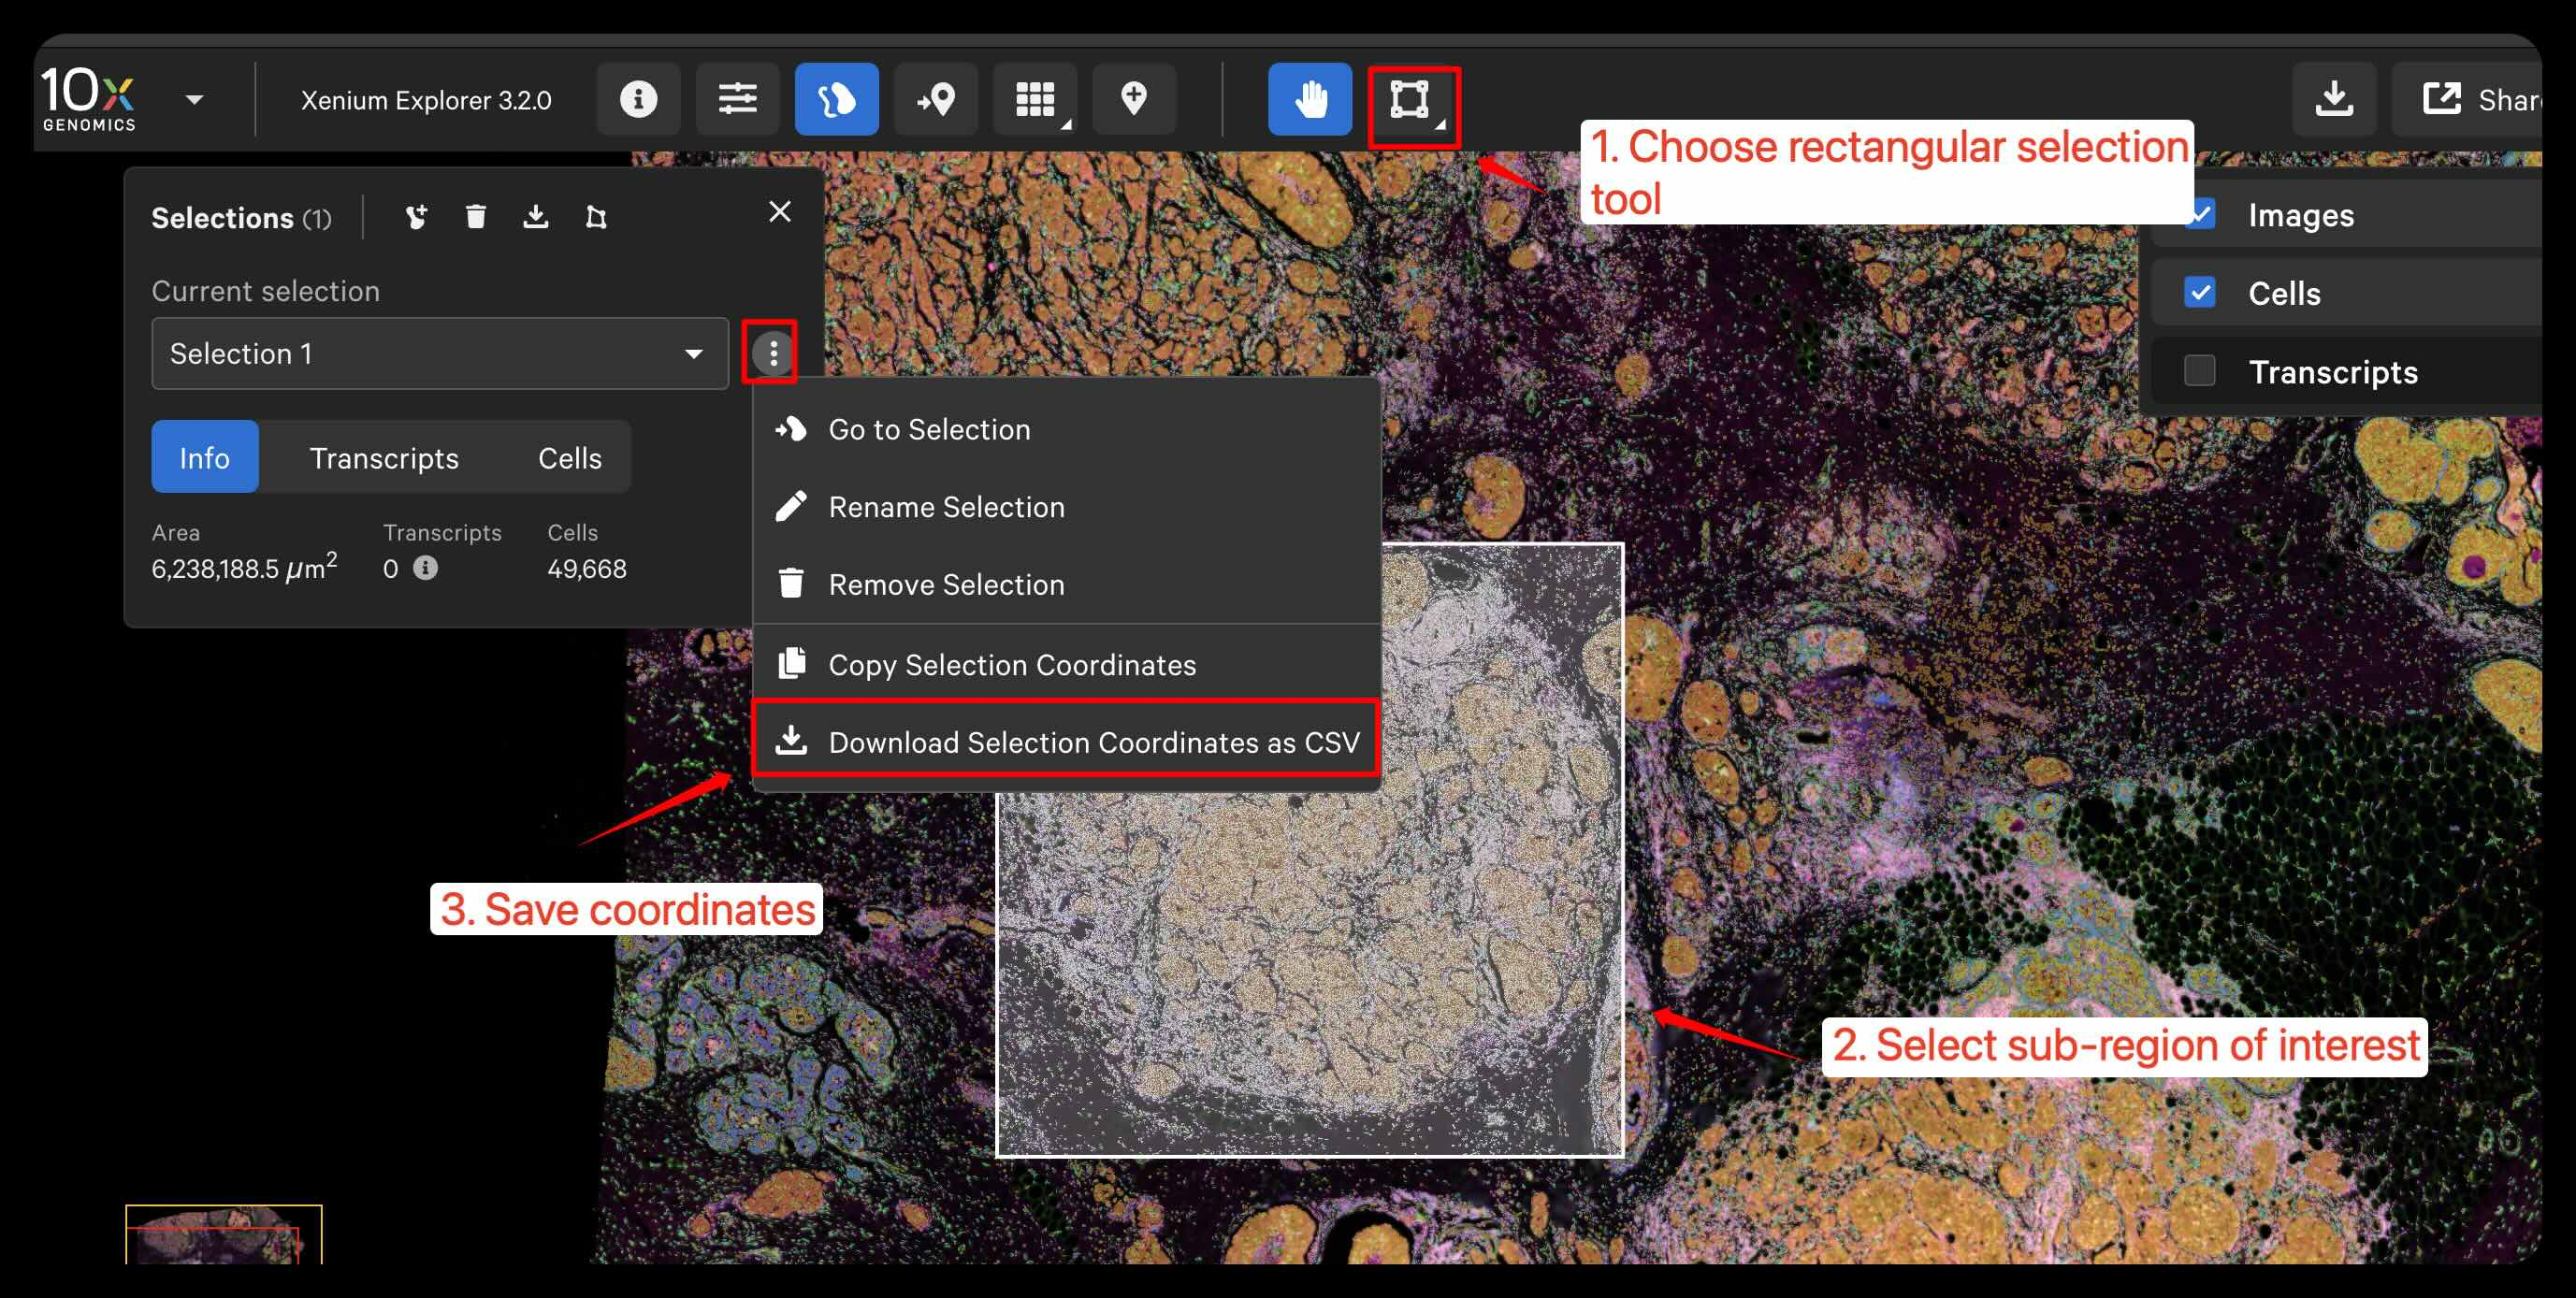

At the hands-on workshop, to save time, you can use the file link below to directly load the CSV into this notebook.

In [ ]:
# Use command line to download pre-selected Selection_1_coordinates.csv
!wget https://cf.10xgenomics.com/supp/xenium/analysis-workshop/Selection_1_coordinates.csv

In [ ]:
# Use the spatialdata_io library, aliased as sio
# Process these coordinates and stores as polygon
polygon = sio.xenium_explorer_selection("Selection_1_coordinates.csv")

Please note, this should be coordinates from one selection, not mulitple selections.

In [ ]:
# # Crop a subset of spatialdata based on the coordinates
# # This step takes ~5 mins, so we pre-run this and load the saved object for the next steps
#from spatialdata import polygon_query

#def crop0(x, polygon):
#     return polygon_query(
#         x,
#         polygon,
#         target_coordinate_system="global",
#     )

#cropped_sdata = crop0(sd_data, polygon)
#cropped_sdata.write("cropped_sdata.zarr")
#!zip -r0 cropped_sdata.zarr.zip cropped_sdata.zarr

#Download and load the pre-generated object of sub-region
#!gdown "19sOfLbN_CThG3hAVK9IEGjxwwj-dSOT5" #update this with the wget line
!wget  https://cf.10xgenomics.com/supp/xenium/analysis-workshop/cropped_sdata_v2.zarr.zip
!unzip cropped_sdata_v2.zarr.zip


cropped_sdata = sd.read_zarr("cropped_sdata_v2.zarr")
cropped_sdata

In [ ]:
# --- Colab memory hygiene ---
# We're done with the full slide. Free sd_data (and the adata view into it)
# before loading the cropped subset; otherwise both objects sit in RAM
for _name in ('adata', 'sd_data'):
    if _name in globals():
        del globals()[_name]
gc.collect()

In [ ]:
cropped_sdata.table

## 4.2 Plot different clusters ###

Now that we have cropped the data, we can visualize the data more quickly and focus on a specific tumor region.

In [ ]:
# Link the cropped AnnData table to the spatial element "cell_boundaries"
cropped_sdata.tables["table"].obs["region"] = "cell_boundaries"
cropped_sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

In [ ]:
#Plot total transcript counts in the region of interest
cropped_sdata.pl.render_shapes("cell_boundaries", color = "transcript_counts", method="datashader").pl.show(title="")

In [ ]:
# Plot the leiden clusters generated during preprocessing steps
cropped_sdata.pl.render_shapes("cell_boundaries", color = "leiden", method="datashader").pl.show(title="")

**Quiz:** In the previous section we manually annotated the cell types in our data and stored the results in the obs layer of the AnnData object. How would you plot these annotations in the spatial view of our region of interest?

##4.3 Plot different genes ##

In [ ]:
# Plot genes
cropped_sdata.pl.render_points(
    "transcripts",
    color="feature_name",
    groups="CCND1",
    palette="red",
    size = 0.2,
    alpha = 0.75,
).pl.show()

**Quiz:** Can you plot 3 genes (*CCND1*, *TRBC1*, *CD19*) in different colors? Hint: to list multiple genes, use brackets and commmas.

- *CCND1*: General Breast Cancer
- *TRBC1*: T Cells
- *CD19*: B Cells

What patterns do you notice for these genes across the sub-region of interest?